
| Demo | 對應課程段落 | 核心 UQ 操作 |
|---|---|---|
| 1 | Part 2 · Bayesian predictive UQ | prior → posterior → predictive → check（Beta-Binomial CTR）|
| 2 | Part 3 · Computation | Monte Carlo 收斂與 MCSE：computational uncertainty 的量化 |
| 3 | Part 6 · Deep learning UQ | 真實訓練的 deep ensemble：total / aleatoric / epistemic 分解地圖 |
| 4 | Part 7 · Deployment | covariate shift 下 accuracy、confidence 與 disagreement 的行為 |

執行需求：`numpy`、`scipy`、`matplotlib`（皆為常見科學計算套件）。

In [2]:
!pip install scipy

  Using cached scipy-1.18.0-cp313-cp313-win_amd64.whl.metadata (61 kB)
Using cached scipy-1.18.0-cp313-cp313-win_amd64.whl (36.6 MB)


## 0. 環境設定

統一視覺樣式（與投影片同一組色票：navy `#1E2761`、blue `#3B6BC9`、red `#C0392B`），並定義輸出資料夾與存檔函式。

In [14]:
import numpy as np
from pathlib import Path
import matplotlib
import matplotlib.pyplot as plt
from scipy import stats

OUT = Path("demo_outputs")
OUT.mkdir(exist_ok=True)

NAVY = "#1E2761"
BLUE = "#3B6BC9"
RED = "#C0392B"
GRAY = "#6B7280"
ICE = "#CADCFC"

polt = plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titleweight": "bold",
    "axes.titlesize": 12,
    "axes.labelsize": 10.5,
    "axes.labelcolor": "#374151",
    "xtick.color": "#374151",
    "ytick.color": "#374151",
    "xtick.labelsize": 9.5,
    "ytick.labelsize": 9.5,
    "legend.frameon": False,
    "figure.facecolor": "white",
})


def save(fig, stem):
    for ext in ("png", "svg"):
        fig.savefig(OUT / f"{stem}.{ext}", dpi=200, bbox_inches="tight", facecolor="white")
    print(f"saved {stem}")




## Demo 1 · Bayesian predictive workflow（Beta-Binomial CTR）

**對應投影片**：Running Example: Beta-Binomial CTR、Credible vs Predictive Intervals、Posterior Predictive Check。

設定：prior 為 Beta(2, 98)（先驗平均 CTR 2%、先驗強度約 100 次曝光），觀察 500 次曝光中的點擊數，真實 CTR 設為 3.5%。三個面板各自展示一個「不同的 uncertainty 物件」：

1. **左**：posterior 是 prior 與資料的折衷（shrinkage）。posterior mean 落在 prior mean 與觀察比例之間，這對應 BDA3 §2.2「posterior as compromise」。
2. **中**：對「未來 500 次曝光的 clicks」的 posterior predictive 區間，比把 posterior mean 當真值的 plug-in Binomial 區間更寬——差距就是 **parameter uncertainty 的貢獻**。這是 credible interval 與 predictive interval 不可互換的直接證據。
3. **右**：posterior predictive check——把觀測值放回 replicated data 的分布中，檢查模型是否能生成像觀測資料的資料（BDA3 §6.3）。尾機率接近 0.5 表示無明顯衝突；接近 0 或 1 才是警訊。

observed y=26/500  (rate 0.0520), prior mean 0.0200
posterior Beta(28,572) mean=0.0467  95% CrI=[0.0313,0.0649]
posterior predictive 95% [12,37]  vs plug-in [15,33]
PPC tail prob P(y_rep >= y) = 0.336
saved demo1_bayesian_workflow


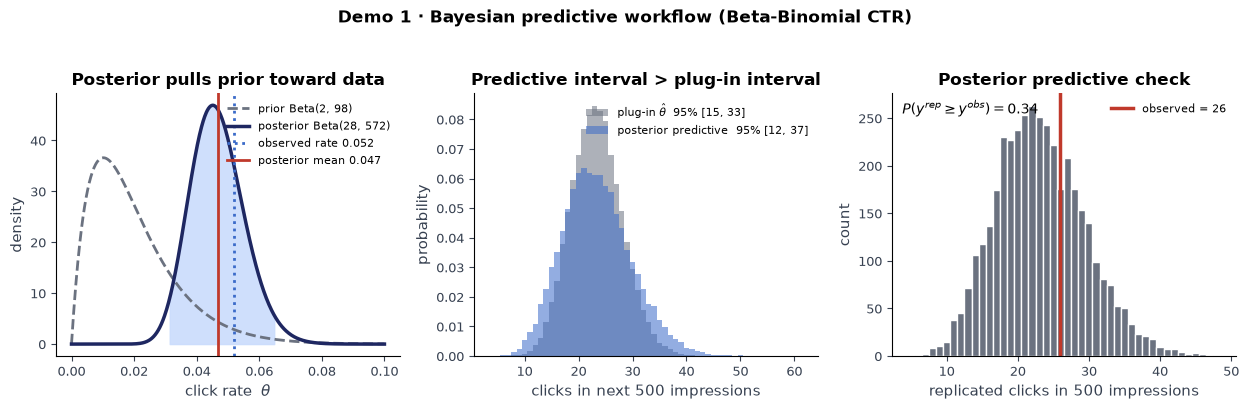

In [15]:
%matplotlib inline

rng = np.random.default_rng(20260705)
a0, b0 = 2.0, 98.0            # prior: mean 2%, prior strength ~ 100 impressions
true_theta = 0.035
n = 500
y = int(rng.binomial(n, true_theta))
a1, b1 = a0 + y, b0 + n - y

prior = stats.beta(a0, b0)
post = stats.beta(a1, b1)
mle = y / n
prior_mean = a0 / (a0 + b0)
post_mean = a1 / (a1 + b1)
ci_lo, ci_hi = post.ppf(0.025), post.ppf(0.975)

# posterior predictive for next m impressions vs plug-in binomial
m = 500
S = 40_000
theta_draws = post.rvs(S, random_state=rng)
y_next = rng.binomial(m, theta_draws)                    # posterior predictive
y_plug = rng.binomial(m, post_mean, size=S)              # plug-in (ignores theta uncertainty)
pp_lo, pp_hi = np.percentile(y_next, [2.5, 97.5])
pl_lo, pl_hi = np.percentile(y_plug, [2.5, 97.5])

# posterior predictive check: replicate the observed experiment
y_rep = rng.binomial(n, post.rvs(4000, random_state=rng))
ppc_p = float(np.mean(y_rep >= y))

print(f"observed y={y}/{n}  (rate {mle:.4f}), prior mean {prior_mean:.4f}")
print(f"posterior Beta({a1:.0f},{b1:.0f}) mean={post_mean:.4f}  95% CrI=[{ci_lo:.4f},{ci_hi:.4f}]")
print(f"posterior predictive 95% [{pp_lo:.0f},{pp_hi:.0f}]  vs plug-in [{pl_lo:.0f},{pl_hi:.0f}]")
print(f"PPC tail prob P(y_rep >= y) = {ppc_p:.3f}")

fig, axes = plt.subplots(1, 3, figsize=(12.6, 3.9))

ax = axes[0]
tt = np.linspace(0, 0.10, 600)
ax.plot(tt, prior.pdf(tt), color=GRAY, lw=2, ls="--", label=f"prior Beta({a0:.0f}, {b0:.0f})")
ax.plot(tt, post.pdf(tt), color=NAVY, lw=2.5, label=f"posterior Beta({a1:.0f}, {b1:.0f})")
ax.fill_between(tt, 0, post.pdf(tt), where=(tt >= ci_lo) & (tt <= ci_hi), color=ICE, alpha=0.9)
ax.axvline(mle, color=BLUE, ls=":", lw=2, label=f"observed rate {mle:.3f}")
ax.axvline(post_mean, color=RED, lw=2, label=f"posterior mean {post_mean:.3f}")
ax.set_xlabel(r"click rate  $\theta$")
ax.set_ylabel("density")
ax.set_title("Posterior pulls prior toward data")
ax.legend(fontsize=8, loc="upper right")

ax = axes[1]
bins = np.arange(min(y_next.min(), y_plug.min()) - 0.5, max(y_next.max(), y_plug.max()) + 1.5)
ax.hist(y_plug, bins=bins, density=True, color=GRAY, alpha=0.55,
        label=f"plug-in $\\hat\\theta$  95% [{pl_lo:.0f}, {pl_hi:.0f}]")
ax.hist(y_next, bins=bins, density=True, color=BLUE, alpha=0.55,
        label=f"posterior predictive  95% [{pp_lo:.0f}, {pp_hi:.0f}]")
ax.set_xlabel(f"clicks in next {m} impressions")
ax.set_ylabel("probability")
ax.set_title("Predictive interval > plug-in interval")
ax.legend(fontsize=8)

ax = axes[2]
ax.hist(y_rep, bins=np.arange(y_rep.min() - 0.5, y_rep.max() + 1.5), color=GRAY, edgecolor="white")
ax.axvline(y, color=RED, lw=2.5, label=f"observed = {y}")
ax.text(0.03, 0.92, f"$P(y^{{rep}} \\geq y^{{obs}}) = {ppc_p:.2f}$", transform=ax.transAxes, fontsize=10)
ax.set_xlabel(f"replicated clicks in {n} impressions")
ax.set_ylabel("count")
ax.set_title("Posterior predictive check")
ax.legend(fontsize=8)

fig.suptitle("Demo 1 · Bayesian predictive workflow (Beta-Binomial CTR)", fontweight="bold", y=1.04)
fig.tight_layout()
save(fig, "demo1_bayesian_workflow")

plt.show()

三張圖回答三個不同問題——「θ 可能是多少」（credible interval）、「下一批資料可能長怎樣」（predictive interval）、「模型有沒有明顯不合」（PPC）。同一個 posterior，摘要對象不同，能支撐的 claim 就不同。

## Demo 2 · Monte Carlo 收斂與 computational uncertainty

**對應投影片**：Computational Uncertainty、Monte Carlo as Numerical Integration。

用一個三輸入的玩具 simulator 估計 failure probability P(f(X) > 2.8)：

1. **左**：單次長跑的 running estimate，加上 ±2 MCSE 帶。MCSE 是「模擬誤差本身的 uncertainty 量化」，報告 UQ 結果時應一併報告（BDA3 §10.5）。
2. **右**：300 次重複實驗的 RMSE 對 N 的 log-log 圖，貼著 c·N^(−1/2) 參考線——要把誤差減半，需要 4 倍樣本；rate 與維度無關，但常數可能很大（稀有事件時更明顯）。

saved demo2_mc_convergence
reference failure prob = 0.17147; RMSE table: {100: 0.03647, 300: 0.02213, 1000: 0.01061, 3000: 0.00724, 10000: 0.00406}


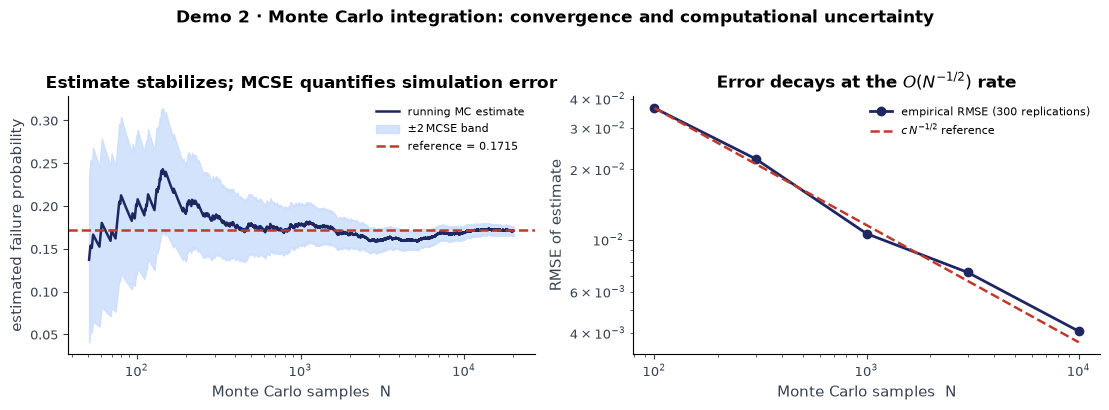

In [16]:
def qoi(x):
    """simulator output for 3 uncertain inputs (columns of x)."""
    return np.sin(x[:, 0]) + 0.4 * x[:, 1] ** 2 + 0.15 * x[:, 0] * x[:, 2]


THRESH = 2.8
rng2 = np.random.default_rng(42)

def draw_inputs(size, rng):
    return rng.uniform(-np.pi, np.pi, size=(size, 3))

# reference from a very large run
ref = float(np.mean(qoi(draw_inputs(2_000_000, np.random.default_rng(7))) > THRESH))

# (a) one long run: running estimate with +-2 MCSE band
N_max = 20_000
fail = (qoi(draw_inputs(N_max, rng2)) > THRESH).astype(float)
Ns = np.arange(1, N_max + 1)
run_est = np.cumsum(fail) / Ns
mcse = np.sqrt(np.clip(run_est * (1 - run_est), 1e-12, None) / Ns)

# (b) RMSE across replications vs N
sizes = np.array([100, 300, 1_000, 3_000, 10_000])
R = 300
rmse = []
for N in sizes:
    ests = np.array([np.mean(qoi(draw_inputs(N, np.random.default_rng(1000 + r * 7 + N))) > THRESH)
                     for r in range(R)])
    rmse.append(np.sqrt(np.mean((ests - ref) ** 2)))
rmse = np.array(rmse)

fig, axes = plt.subplots(1, 2, figsize=(11.2, 3.9))

ax = axes[0]
sl = slice(50, None)
ax.plot(Ns[sl], run_est[sl], color=NAVY, lw=1.8, label="running MC estimate")
ax.fill_between(Ns[sl], (run_est - 2 * mcse)[sl], (run_est + 2 * mcse)[sl],
                color=ICE, alpha=0.8, label=r"$\pm 2\,$MCSE band")
ax.axhline(ref, color=RED, ls="--", lw=1.8, label=f"reference = {ref:.4f}")
ax.set_xscale("log")
ax.set_xlabel("Monte Carlo samples  N")
ax.set_ylabel("estimated failure probability")
ax.set_title("Estimate stabilizes; MCSE quantifies simulation error")
ax.legend(fontsize=8, loc="upper right")

ax = axes[1]
ax.loglog(sizes, rmse, "o-", color=NAVY, lw=2, label=f"empirical RMSE ({R} replications)")
cref = rmse[0] * np.sqrt(sizes[0])
ax.loglog(sizes, cref / np.sqrt(sizes), ls="--", color=RED, lw=1.8, label=r"$c\,N^{-1/2}$ reference")
ax.set_xlabel("Monte Carlo samples  N")
ax.set_ylabel("RMSE of estimate")
ax.set_title(r"Error decays at the $O(N^{-1/2})$ rate")
ax.legend(fontsize=8)

fig.suptitle("Demo 2 · Monte Carlo integration: convergence and computational uncertainty",
             fontweight="bold", y=1.04)
fig.tight_layout()
save(fig, "demo2_mc_convergence")
print(f"reference failure prob = {ref:.5f}; RMSE table: {dict(zip(sizes.tolist(), np.round(rmse,5).tolist()))}")

## Demo 3 · Deep ensemble 的不確定性分解（真實訓練）

**對應投影片**：Ensembles Approximate P(h)、Entropy Can Mix Ambiguity and Ignorance。

與舊版用手工設定機率不同，這裡**實際訓練** 10 個小型 MLP（1 隱藏層、tanh、不同隨機初始化 + bootstrap 重抽樣），在 two-moons 資料上形成一個 deep ensemble，然後在整個輸入平面上計算：

- **Total**：H(p̄)，平均預測的 entropy；
- **Aleatoric 部分**：E_m[H(p_m)]，各成員自己覺得多模糊（類別重疊）；
- **Epistemic 部分**：H(p̄) − E_m[H(p_m)]（mutual information / Jensen-Shannon 型分歧），成員彼此多不同意。

預期圖形：**類別交界**處 aleatoric 高（每個網路都模糊、但彼此一致）；**訓練資料支撐外**的區域 epistemic 高（每個網路都很自信、但方向不同）。

saved demo3_ensemble_maps
ensemble train accuracy = 0.993; max MI on grid = 0.606


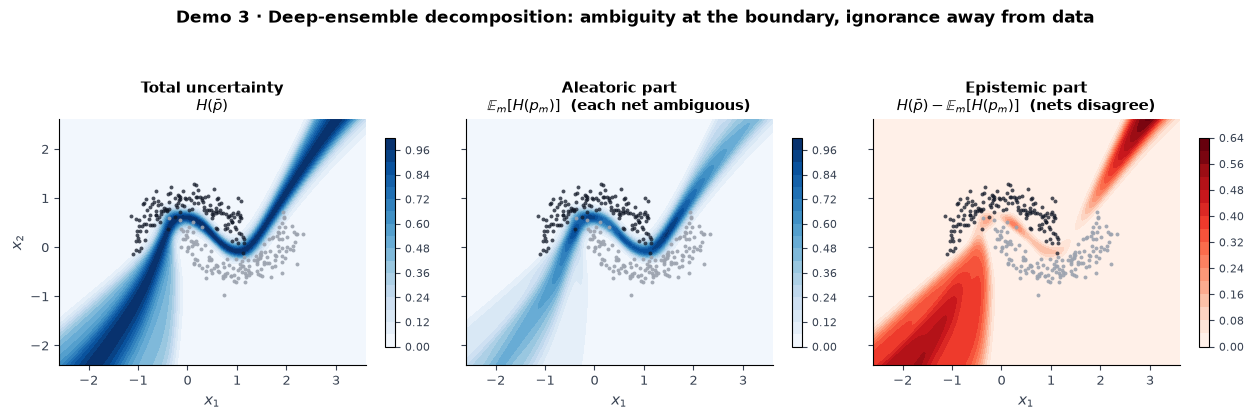

In [ ]:
def make_moons(n_per_class, noise, rng):
    t = rng.uniform(0, np.pi, n_per_class)
    x1 = np.c_[np.cos(t), np.sin(t)]
    t2 = rng.uniform(0, np.pi, n_per_class)
    x2 = np.c_[1 - np.cos(t2), 0.5 - np.sin(t2)]
    X = np.vstack([x1, x2]) + rng.normal(0, noise, size=(2 * n_per_class, 2))
    ylab = np.r_[np.zeros(n_per_class), np.ones(n_per_class)]
    return X, ylab


class TinyMLP:
    """1-hidden-layer MLP trained with plain gradient descent + momentum."""

    def __init__(self, hidden, rng):
        self.W1 = rng.normal(0, 1.0, (2, hidden))
        self.b1 = np.zeros(hidden)
        self.W2 = rng.normal(0, 1.0, (hidden, 1))
        self.b2 = np.zeros(1)

    def forward(self, X):
        self.Z1 = np.tanh(X @ self.W1 + self.b1)
        z2 = self.Z1 @ self.W2 + self.b2
        return 1 / (1 + np.exp(-z2[:, 0]))

    def fit(self, X, ylab, epochs=1500, lr=0.08, mom=0.9, l2=1e-4):
        vel = [np.zeros_like(p) for p in (self.W1, self.b1, self.W2, self.b2)]
        n_samp = len(X)
        for _ in range(epochs):
            p = self.forward(X)
            err = (p - ylab)[:, None] / n_samp
            gW2 = self.Z1.T @ err + l2 * self.W2
            gb2 = err.sum(0)
            dZ1 = (err @ self.W2.T) * (1 - self.Z1 ** 2)
            gW1 = X.T @ dZ1 + l2 * self.W1
            gb1 = dZ1.sum(0)
            for i, (param, grad) in enumerate(zip((self.W1, self.b1, self.W2, self.b2),
                                                  (gW1, gb1, gW2, gb2))):
                vel[i] = mom * vel[i] - lr * grad
                param += vel[i]
        return self


def binary_entropy(p):
    p = np.clip(p, 1e-12, 1 - 1e-12)
    return -(p * np.log2(p) + (1 - p) * np.log2(1 - p))


rng3 = np.random.default_rng(3)
Xtr, ytr = make_moons(150, 0.16, rng3)

M = 10
ensemble = []
for k in range(M):
    r = np.random.default_rng(100 + k)
    idx = r.integers(0, len(Xtr), len(Xtr))          # bootstrap resample
    ensemble.append(TinyMLP(16, r).fit(Xtr[idx], ytr[idx]))

# evaluation grid
gx = np.linspace(-2.6, 3.6, 220)
gy = np.linspace(-2.4, 2.6, 190)
GX, GY = np.meshgrid(gx, gy)
grid = np.c_[GX.ravel(), GY.ravel()]

P = np.stack([net.forward(grid) for net in ensemble])   # (M, n_grid)
p_mean = P.mean(0)
H_total = binary_entropy(p_mean)
H_expected = binary_entropy(P).mean(0)
MI = np.clip(H_total - H_expected, 0, None)

fig, axes = plt.subplots(1, 3, figsize=(12.8, 3.9), sharey=True)
titles = ["Total uncertainty\n" + r"$H(\bar{p})$",
          "Aleatoric part\n" + r"$\mathbb{E}_m[H(p_m)]$  (each net ambiguous)",
          "Epistemic part\n" + r"$H(\bar{p}) - \mathbb{E}_m[H(p_m)]$  (nets disagree)"]
fields = [H_total, H_expected, MI]
vmaxs = [1.0, 1.0, max(0.35, MI.max())]
cmaps = ["Blues", "Blues", "Reds"]
for ax, ttl, field, vmx, cm in zip(axes, titles, fields, vmaxs, cmaps):
    im = ax.contourf(GX, GY, field.reshape(GX.shape), levels=18, cmap=cm, vmin=0, vmax=vmx)
    ax.scatter(*Xtr[ytr == 0].T, s=8, c="#111827", alpha=0.75, lw=0)
    ax.scatter(*Xtr[ytr == 1].T, s=8, c="#9CA3AF", alpha=0.9, lw=0)
    ax.set_title(ttl, fontsize=10.5)
    ax.set_xlabel(r"$x_1$")
    cb = fig.colorbar(im, ax=ax, shrink=0.85)
    cb.ax.tick_params(labelsize=8)
axes[0].set_ylabel(r"$x_2$")
fig.suptitle("Demo 3 · Deep-ensemble decomposition: ambiguity at the boundary, ignorance away from data",
             fontweight="bold", y=1.06)
fig.tight_layout()
save(fig, "demo3_ensemble_maps")

acc_train = np.mean((np.mean(np.stack([net.forward(Xtr) for net in ensemble]), 0) > 0.5) == ytr)
print(f"ensemble train accuracy = {acc_train:.3f}; max MI on grid = {MI.max():.3f}")

## Demo 4 · Dataset shift

**對應投影片**：Shift and Open-World Cases、Monitoring Is Screening Until Labels Arrive。

把測試資料沿兩個不同方向逐步平移（covariate shift），觀察 ensemble accuracy、單一網路的平均 confidence、以及 ensemble disagreement（MI）：

- **方向 A**：accuracy 下降時 disagreement 明顯上升——uncertainty 訊號可以把 shift 樣本挑出來優先審查（screening 有效）。
- **方向 B**：accuracy 掉到 chance level，但所有成員**一致且自信地錯**，MI 反而趨近 0——「confidently wrong」。這示範 Ovadia et al. 的核心訊息：in-distribution 驗證過的 uncertainty 不保證在 shift 下仍可靠；也支持投影片的說法——**訊號只能 screening，不能證明失敗**，最終仍需要 labels 或人工審查（Lu et al. 的 drift 框架）。

saved demo4_shift
dir A: acc [0.978 0.752 0.749]  MI [0.007 0.186 0.324]
dir B: acc [0.978 0.5   0.5  ]  conf [0.984 1.    1.   ]  MI [0.007 0.026 0.   ]


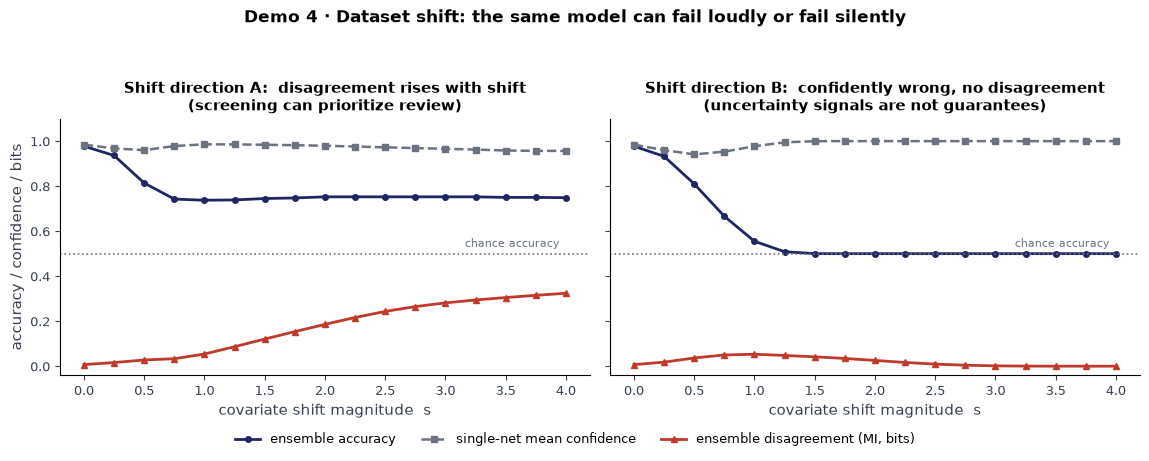

In [18]:
rng4 = np.random.default_rng(11)
Xte, yte = make_moons(400, 0.16, rng4)
shifts = np.linspace(0, 4.0, 17)

def eval_shift(direction):
    dv = np.asarray(direction, float)
    dv = dv / np.linalg.norm(dv)
    acc, conf, mi = [], [], []
    for s in shifts:
        Xs = Xte + s * dv
        Ps = np.stack([net.forward(Xs) for net in ensemble])
        pm = Ps.mean(0)
        acc.append(np.mean((pm > 0.5) == yte))
        ps = ensemble[0].forward(Xs)
        conf.append(np.mean(np.maximum(ps, 1 - ps)))
        mi.append(np.mean(np.clip(binary_entropy(pm) - binary_entropy(Ps).mean(0), 0, None)))
    return np.array(acc), np.array(conf), np.array(mi)

resA = eval_shift((-0.6, -1.0))   # ensemble members disagree -> screening works
resB = eval_shift((0.3, -1.0))    # members agree and stay confident -> screening fails

fig, axes = plt.subplots(1, 2, figsize=(11.6, 4.0), sharey=True)
panels = [
    (resA, "Shift direction A:  disagreement rises with shift\n(screening can prioritize review)"),
    (resB, "Shift direction B:  confidently wrong, no disagreement\n(uncertainty signals are not guarantees)"),
]
for ax, ((acc, conf, mi), ttl) in zip(axes, panels):
    ax.plot(shifts, acc, "o-", color=NAVY, lw=2, ms=4, label="ensemble accuracy")
    ax.plot(shifts, conf, "s--", color=GRAY, lw=1.8, ms=4, label="single-net mean confidence")
    ax.plot(shifts, mi, "^-", color=RED, lw=2, ms=4, label="ensemble disagreement (MI, bits)")
    ax.axhline(0.5, color=GRAY, ls=":", lw=1.2)
    ax.text(3.95, 0.53, "chance accuracy", fontsize=8, color=GRAY, ha="right")
    ax.set_xlabel("covariate shift magnitude  s")
    ax.set_ylim(-0.04, 1.1)
    ax.set_title(ttl, fontsize=10.5)
axes[0].set_ylabel("accuracy / confidence / bits")
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, ncol=3, fontsize=9, loc="lower center", bbox_to_anchor=(0.5, -0.06))
fig.suptitle("Demo 4 · Dataset shift: the same model can fail loudly or fail silently",
             fontweight="bold", y=1.06)
fig.tight_layout()
save(fig, "demo4_shift")
print("dir A: acc", np.round(resA[0][[0, 8, -1]], 3), " MI", np.round(resA[2][[0, 8, -1]], 3))
print("dir B: acc", np.round(resB[0][[0, 8, -1]], 3), " conf", np.round(resB[1][[0, 8, -1]], 3),
      " MI", np.round(resB[2][[0, 8, -1]], 3))

## Takeaways

1. **Demo 1**：先命名 uncertainty 物件（θ？未來資料？模型合理性？），再選 summary；credible 與 predictive interval 不可互換。
2. **Demo 2**：computation 是 claim 的一部分；MCSE 與收斂診斷要和 UQ 結果一起報告。
3. **Demo 3**：ensemble 分解把「模糊」與「無知」分開，但它是近似診斷，不是 exact posterior，也不是 OOD 證明。
4. **Demo 4**：部署監控是 labels 到來前的 screening；uncertainty 訊號有用但不是保證，監控設計要把訊號接到行動（defer / label / recalibrate / retrain）。